# Colab 31 — Locked development baseline: LR / Balanced Accuracy

## Quy trình được chốt từ Lab 30
Baseline là **quy trình `lr_ba_inner_selected`**, không phải một bộ hyperparameter
được lấy từ outer test. Không SMOTENC, không few-shot, threshold cố định **0.5**.

- Development: Cleveland, Switzerland, VA (626 ca thật).
- P1 sentinel handling; train-only median/mode imputation, numeric scaling,
  missing indicators và one-hot encoding như Lab 30.
- Grid cố định: C = [0.01, 0.1, 1, 10]; class weight = None, balanced,
  hoặc {0:1, 1:w}, w trong [0.25, 0.5, 0.75, 1.5, 2, 4].
- Chọn đủ biến hoặc bỏ ca/thal **trong inner CV**.
- Objective: macro Balanced Accuracy, tie-break worst-inner-site BA rồi thứ tự grid.
- Outer LOCO báo cáo đánh giá; không dùng outer score để sửa grid, threshold hoặc chọn seed.
- Seed cố định 42: LR lbfgs không sampling; Lab 30 cho cùng lựa chọn ở ba seeds.
- Final selection dùng LOCO trên cả 3 development hospitals, sau đó fit cả 626 ca.
- Hungarian không được tải/đánh giá. Final CV score là score chọn cấu hình, không phải independent test.

## Mốc đã quan sát trong Lab 30 (không phải output chạy Colab 31)
Macro BA 0.7014; Accuracy 0.7686; Recall 0.8605; Specificity 0.5423;
ROC-AUC 0.7574; Brier 0.1607; worst-site BA 0.6457; worst-site Recall 0.8261.
Inner selection chọn bỏ ca/thal ở mọi outer fold. Final selection vẫn phải chạy
trên development, không tự gán C/weight từ một outer fold.

Đây là baseline nghiên cứu đã chọn sau các thí nghiệm exploratory, không phải
mô hình đã được xác nhận trên bệnh viện mới hoặc model production.

In [1]:
!pip -q install "scikit-learn==1.6.1" "imbalanced-learn==0.13.0" "optuna==4.2.1" seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 238.4/238.4 kB 3.3 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.6/383.6 kB 9.5 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 12.0 MB/s eta 0:00:00


In [2]:
import json
import random
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import seaborn as sns
from IPython.display import display
from imblearn.over_sampling import SMOTENC
from scipy.special import expit
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("default")
optuna.logging.set_verbosity(optuna.logging.WARNING)
pd.set_option("display.max_columns", 100)

FEATURES = [
    "age", "sex", "cp", "trestbps", "chol", "fbs", "restecg",
    "thalach", "exang", "oldpeak", "slope", "ca", "thal",
]
TARGET = "target"
SITE = "site"
NUMERICAL_FEATURES = ["age", "trestbps", "chol", "thalach", "oldpeak"]
CATEGORICAL_FEATURES = [
    "sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal",
]

BASE_URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease"
FILES = {
    "cleveland": "processed.cleveland.data",
    "switzerland": "processed.switzerland.data",
    "va": "processed.va.data",
}
COLUMNS = FEATURES + ["num"]
DEVELOPMENT_SITES = ["cleveland", "switzerland", "va"]

MODEL_SEEDS = (42,)
N_TRIALS = 10
THRESHOLD = 0.50

OUTPUT_DIR = Path("/content/uci_multicenter_locked_baseline_lab31_results")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

LOCAL_DATA_DIR_CANDIDATES = [
    Path("/content/heart-disease-diagnosis/data/raw/uci_multicenter"),
    Path("/content/data/raw/uci_multicenter"),
    Path("data/raw/uci_multicenter"),
    Path("../data/raw/uci_multicenter"),
]
LOCAL_DATA_DIR = next(
    (path for path in LOCAL_DATA_DIR_CANDIDATES if path.exists()),
    None,
)

print("Development sites:", DEVELOPMENT_SITES)
print("Model seeds:", MODEL_SEEDS)
print("External holdout loaded:", False)
from sklearn.metrics import balanced_accuracy_score
import platform, importlib.metadata, shutil

C_GRID = (0.01, 0.1, 1.0, 10.0)
# Numeric weights are {0: 1, 1: weight}; balanced is learned from each train fold.
WEIGHT_GRID = (None, 'balanced', 0.25, 0.5, 0.75, 1.5, 2.0, 4.0)
THRESHOLD = 0.5
LOCAL_DATA_DIR_CANDIDATES += [Path('../../data/raw/uci_multicenter')]
LOCAL_DATA_DIR = next((p for p in LOCAL_DATA_DIR_CANDIDATES if p.exists()), None)
SEED = 42
warnings.filterwarnings("ignore", category=DeprecationWarning)

Development sites: ['cleveland', 'switzerland', 'va']
Model seeds: (42,)
External holdout loaded: False


In [3]:
def read_uci(site, filename):
    source = (LOCAL_DATA_DIR / filename) if LOCAL_DATA_DIR else f"{BASE_URL}/{filename}"
    frame = pd.read_csv(
        source,
        names=COLUMNS,
        na_values=["?"],
        skipinitialspace=True,
    )
    frame = frame.apply(pd.to_numeric, errors="coerce")
    assert frame["num"].notna().all()
    assert frame["num"].isin([0, 1, 2, 3, 4]).all()
    frame[TARGET] = (frame["num"] > 0).astype("int8")
    frame[SITE] = site
    return frame[FEATURES + [TARGET, SITE]]


development = pd.concat(
    [read_uci(site, filename) for site, filename in FILES.items()],
    ignore_index=True,
)

assert len(development) == 626
assert set(development[SITE]) == set(DEVELOPMENT_SITES)

site_summary = development.groupby(SITE).agg(
    rows=(TARGET, "size"),
    positives=(TARGET, "sum"),
    positive_rate=(TARGET, "mean"),
).reset_index()

missing_by_site = development.groupby(SITE)[FEATURES].apply(
    lambda frame: frame.isna().mean()
).T

print("Data source:", str(LOCAL_DATA_DIR) if LOCAL_DATA_DIR else "UCI URL fallback")
print("Development shape:", development.shape)
display(site_summary.round(4))
display(pd.crosstab(development[SITE], development[TARGET], margins=True))
display((missing_by_site * 100).round(1))

site_summary.to_csv(OUTPUT_DIR / "development_site_summary.csv", index=False)
missing_by_site.to_csv(OUTPUT_DIR / "development_missing_by_site.csv")

Data source: UCI URL fallback
Development shape: (626, 15)


,site,rows,positives,positive_rate
0,cleveland,303,139,0.4587
1,switzerland,123,115,0.9350
2,va,200,149,0.7450


target,0,1,All
site,,,
cleveland,164,139,303
switzerland,8,115,123
va,51,149,200
All,223,403,626


site,cleveland,switzerland,va
age,0.0,0.0,0.0
sex,0.0,0.0,0.0
cp,0.0,0.0,0.0
trestbps,0.0,1.6,28.0
chol,0.0,0.0,3.5
fbs,0.0,61.0,3.5
restecg,0.0,0.8,0.0
thalach,0.0,0.8,26.5
exang,0.0,0.8,26.5
oldpeak,0.0,4.9,28.0


In [4]:
def apply_p1(frame):
    out = frame.copy()
    for column in FEATURES:
        out[column] = pd.to_numeric(out[column], errors="coerce")

    # P1: sentinel đã được đọc thành NaN; thêm rule có căn cứ cho giá trị không hợp lệ.
    for column in ["trestbps", "chol"]:
        out.loc[out[column] <= 0, column] = np.nan

    return out

In [5]:
def fit_controlled(train, config, C, ratio, seed):
    features = [f for f in FEATURES if not (config['drop'] and f in ['ca', 'thal'])]
    numeric = [f for f in NUMERICAL_FEATURES if f in features]
    categorical = [f for f in CATEGORICAL_FEATURES if f in features]
    raw = apply_p1(train)[numeric + categorical]
    fill = {}
    for f in raw:
        values = raw[f].dropna()
        fill[f] = (values.median() if f in numeric else values.mode().iloc[0]) if len(values) else 0.0
    scaler = StandardScaler().fit(raw[numeric].fillna(fill))
    def transform(frame):
        x = apply_p1(frame)[numeric + categorical]
        pieces = [scaler.transform(x[numeric].fillna(fill)), x[categorical].fillna(fill).to_numpy()]
        if config['indicators']:
            pieces.append(x.isna().astype(float).to_numpy())
        return np.column_stack(pieces)
    x = transform(train)
    y = train[TARGET].to_numpy()
    cat_indices = list(range(len(numeric), x.shape[1]))
    if config['sampling']:
        counts = np.bincount(y, minlength=2)
        # Do not undersample when requested ratio is already reached.
        if counts.min() < 2:
            raise ValueError('SMOTENC requires at least two samples per class')
        if counts.min() / counts.max() < ratio:
            x, y = SMOTENC(categorical_features=cat_indices, sampling_strategy=ratio,
                k_neighbors=min(5, int(counts.min()) - 1), random_state=seed).fit_resample(x, y)
    encoder = ColumnTransformer([
        ('numeric', 'passthrough', list(range(len(numeric)))),
        ('categorical', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_indices),
    ])
    model = LogisticRegression(C=C, class_weight=config.get('class_weight', 'balanced' if config['balanced'] else None),
                               solver='lbfgs', max_iter=3000, random_state=seed)
    model.fit(encoder.fit_transform(x), y)
    return lambda frame: model.predict_proba(encoder.transform(transform(frame)))[:, 1]

def metrics(y, p, threshold=0.5):
    pred = (np.asarray(p) >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, pred, labels=[0, 1]).ravel()
    return dict(accuracy=accuracy_score(y, pred), balanced_accuracy=balanced_accuracy_score(y, pred),
        recall=recall_score(y, pred, zero_division=0), specificity=tn/(tn+fp),
        precision=precision_score(y, pred, zero_division=0), f1=f1_score(y, pred, zero_division=0),
        roc_auc=roc_auc_score(y, p), average_precision=average_precision_score(y, p),
        brier=brier_score_loss(y, p), tn=int(tn), fp=int(fp), fn=int(fn), tp=int(tp), n=len(y))

In [6]:
def config_for(drop=False, weight=None, sampling=False):
    return dict(drop=drop, sampling=sampling, balanced=False, indicators=True,
                class_weight=weight if weight in (None, 'balanced') else {0:1.0, 1:float(weight)})

def inner_scores(source, config, C, seed):
    rows=[]
    for hospital in sorted(source[SITE].unique()):
        train=source[source[SITE]!=hospital]
        valid=source[source[SITE]==hospital]
        assert set(train.index).isdisjoint(valid.index)
        assert train[SITE].nunique()==source[SITE].nunique()-1 and valid[SITE].nunique()==1
        predict=fit_controlled(train, config, C, 1.0, seed)
        rows.append(dict(inner_site=hospital, **metrics(valid[TARGET],predict(valid))))
    return rows

def select_candidate(candidates, objective):
    secondary='min_balanced_accuracy' if objective=='balanced_accuracy' else 'macro_accuracy'
    return max(candidates, key=lambda c:(c['macro_'+objective],c[secondary]))

def tune_branch(source, drop, weights, sampling, objective, seed):
    candidates=[]
    for C in C_GRID:
        for weight in weights:
            config=config_for(drop,weight,sampling)
            folds=inner_scores(source,config,C,seed)
            candidates.append(dict(C=C,weight=weight,drop=drop,sampling=sampling,
                macro_accuracy=float(np.mean([f['accuracy'] for f in folds])),
                macro_balanced_accuracy=float(np.mean([f['balanced_accuracy'] for f in folds])),
                min_balanced_accuracy=float(min(f['balanced_accuracy'] for f in folds)),
                folds=folds))
    return select_candidate(candidates,objective),candidates
def select_baseline(source, seed=SEED):
    candidates=[]
    for drop in (False,True):
        _, branch_candidates=tune_branch(source,drop,WEIGHT_GRID,False,'balanced_accuracy',seed)
        candidates.extend(branch_candidates)
    return select_candidate(candidates,'balanced_accuracy'),candidates

def flatten_candidates(candidates,best,stage):
    return [dict(stage=stage,selected=c is best,
        **{k:v for k,v in c.items() if k!='folds'},**fold)
        for c in candidates for fold in c['folds']]

## 1. Nested LOCO — đánh giá quy trình đã khóa

In [7]:
rows,prediction_rows,tuning_rows,selection_rows=[],[],[],[]
for hospital in DEVELOPMENT_SITES:
    source_frame=development[development[SITE]!=hospital]
    test=development[development[SITE]==hospital]
    assert set(source_frame.index).isdisjoint(test.index)
    best,candidates=select_baseline(source_frame)
    tuning_rows.extend(flatten_candidates(candidates,best,'outer_'+hospital))
    selection_rows.append(dict(outer_site=hospital,**{k:v for k,v in best.items() if k!='folds'}))
    predict=fit_controlled(source_frame,config_for(best['drop'],best['weight']),best['C'],1.0,SEED)
    p=predict(test)
    rows.append(dict(site=hospital,**metrics(test[TARGET],p,THRESHOLD)))
    for idx,y,prob in zip(test.index,test[TARGET],p):
        prediction_rows.append(dict(row_id=int(idx),site=hospital,target=int(y),
            probability=float(prob),prediction=int(prob>=THRESHOLD)))
    print('Completed outer:',hospital,flush=True)
site_summary=pd.DataFrame(rows)
predictions=pd.DataFrame(prediction_rows)
METRICS=['balanced_accuracy','accuracy','recall','specificity','precision','f1',
         'roc_auc','average_precision','brier']
macro=site_summary[METRICS].mean().to_dict()
for m in METRICS: macro['worst_'+m]=float(site_summary[m].max() if m=='brier' else site_summary[m].min())
macro_summary=pd.DataFrame([macro])
display(site_summary.round(4))
display(macro_summary.round(4))
display(pd.DataFrame(selection_rows))
assert len(predictions)==626 and predictions.row_id.nunique()==626
assert np.allclose(site_summary.balanced_accuracy,(site_summary.recall+site_summary.specificity)/2)

Completed outer: cleveland
Completed outer: switzerland
Completed outer: va


,site,accuracy,balanced_accuracy,recall,specificity,precision,f1,roc_auc,average_precision,brier,tn,fp,fn,tp,n
0,cleveland,0.7228,0.7329,0.8561,0.6098,0.6503,0.7391,0.8395,0.8327,0.1788,100,64,20,119,303
1,switzerland,0.8130,0.7255,0.8261,0.6250,0.9694,0.8920,0.7185,0.9717,0.1366,5,3,20,95,123
2,va,0.7700,0.6457,0.8993,0.3922,0.8121,0.8535,0.7142,0.8515,0.1667,20,31,15,134,200


,balanced_accuracy,accuracy,recall,specificity,precision,f1,roc_auc,average_precision,brier,worst_balanced_accuracy,worst_accuracy,worst_recall,worst_specificity,worst_precision,worst_f1,worst_roc_auc,worst_average_precision,worst_brier
0,0.7014,0.7686,0.8605,0.5423,0.8106,0.8282,0.7574,0.8853,0.1607,0.6457,0.7228,0.8261,0.3922,0.6503,0.7391,0.7142,0.8327,0.1788


,outer_site,C,weight,drop,sampling,macro_accuracy,macro_balanced_accuracy,min_balanced_accuracy
0,cleveland,1.0,None,True,False,0.803394,0.625815,0.500000
1,switzerland,1.0,0.75,True,False,0.744538,0.721087,0.683379
2,va,0.1,balanced,True,False,0.756581,0.721279,0.708152


## 2. Final development selection và fit
Chọn cấu hình bằng LOCO trên 3 hospitals, mỗi lượt train 2/validation 1.
Không báo cáo hiệu năng trên chính 626 ca dùng final fit.
`final_predict_probability(frame)` có thể dùng trong runtime hiện tại với DataFrame cùng schema;
file notebook không xuất pickle hoặc triển khai model ra platform.

In [8]:
final_best,final_candidates=select_baseline(development)
final_config={k:v for k,v in final_best.items() if k!='folds'}
final_config.update(threshold=THRESHOLD,seed=SEED,
    features=[f for f in FEATURES if not(final_best['drop'] and f in ['ca','thal'])],
    selection_metric='macro development LOCO Balanced Accuracy',
    score_interpretation='selection score, not independent test performance')
final_predict_probability=fit_controlled(development,
    config_for(final_best['drop'],final_best['weight']),final_best['C'],1.0,SEED)
display(pd.DataFrame([final_config]))
final_tuning=pd.DataFrame(flatten_candidates(final_candidates,final_best,'final_development_selection'))

,C,weight,drop,sampling,macro_accuracy,macro_balanced_accuracy,min_balanced_accuracy,threshold,seed,features,selection_metric,score_interpretation
0,0.1,balanced,True,False,0.768325,0.701776,0.645743,0.5,42,"[age, sex, cp, trestbps, chol, fbs, restecg, t...",macro development LOCO Balanced Accuracy,"selection score, not independent test performance"


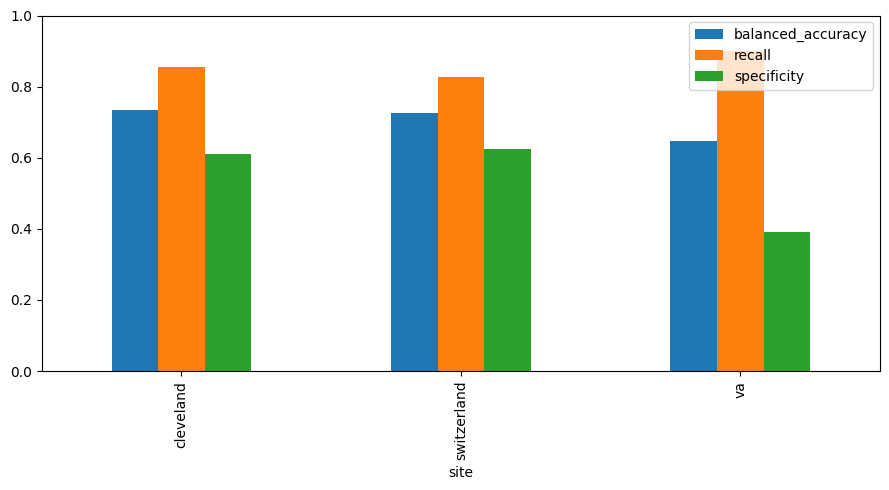

ZIP: /content/uci_multicenter_locked_baseline_lab31_results.zip


In [9]:
import hashlib
for name,frame in dict(site_summary=site_summary,macro_summary=macro_summary,
    outer_predictions=predictions,outer_selected_configs=pd.DataFrame(selection_rows),
    outer_tuning=pd.DataFrame(tuning_rows),final_development_tuning=final_tuning).items():
    frame.to_csv(OUTPUT_DIR/(name+'.csv'),index=False)
(OUTPUT_DIR/'final_config.json').write_text(json.dumps(final_config,indent=2),encoding='utf-8')
protocol=dict(notebook='Lab31',baseline='lr_ba_inner_selected',C_grid=C_GRID,
    weight_grid=WEIGHT_GRID,feature_choices=['all','drop_ca_thal'],threshold=THRESHOLD,seed=SEED,
    primary_metric='macro inner BA',tie_break='worst inner BA, then C/weight/feature grid order',
    development_sites=DEVELOPMENT_SITES,external_holdout_loaded=False,
    data_sha256=hashlib.sha256(development.to_csv(index=False).encode()).hexdigest(),
    versions={p:importlib.metadata.version(p) for p in ['numpy','pandas','scikit-learn','imbalanced-learn']},
    final_model='fitted in runtime only; no model file exported',
    interpretation='exploratory development baseline; Hungarian not evaluated')
(OUTPUT_DIR/'locked_protocol.json').write_text(json.dumps(protocol,indent=2),encoding='utf-8')
ax=site_summary.set_index('site')[['balanced_accuracy','recall','specificity']].plot.bar(figsize=(9,5))
ax.set_ylim(0,1)
plt.tight_layout()
plt.savefig(OUTPUT_DIR/'baseline_per_site.png',dpi=160)
plt.show()
print('ZIP:',shutil.make_archive(str(OUTPUT_DIR),'zip',OUTPUT_DIR))

## Kết luận báo cáo
Phân biệt `macro_summary.csv` (outer evaluation) với `final_config.json` (cấu hình
được chọn để fit development). Không lấy final selection score làm test score.
Không sửa protocol sau khi xem Hungarian. Baseline này không chứng minh clinical utility.

Nguồn phương pháp: [Steyerberg & Harrell, 2016](https://doi.org/10.1016/j.jclinepi.2015.04.005),
[Varma & Simon, 2006](https://doi.org/10.1186/1471-2105-7-91).